# MQ03 — GPT-1 Pre-Training (Decoder-only)
기존 **Encoder-Decoder Transformer** 구조를, GPT-1 논문(*Improving Language Understanding by Generative Pre-Training*, Radford et al., 2018)의 **Decoder-only 생성 모델**로 재구성합니다.

> 본 과제는 **프리트레이닝(다음에 올 토큰 예측)** 과 생성 동작 확인에 초점을 둡니다.  
> (파인튜닝·높은 대화 품질은 평가 범위 밖)

---

## [평가 1] Transformer 대비 변경할 부분 (블록별 설명)

| 블록 | Transformer (원본) | GPT-1 (본 프로젝트) | 변경 이유 |
|------|---------------------|--------------|-----------|
| **전체 구조** | Encoder + Decoder Seq2Seq | **Decoder stack만** | GPT는 단방향 LM — Encoder/Cross-Attn 불필요 |
| **Encoder 블록** | Self-Attn + FFN | **삭제** | 질문만 인코딩하는 경로가 없음 |
| **Decoder 블록** | Masked Self-Attn → **Cross-Attn** → FFN | Masked Self-Attn → FFN (**Cross-Attn 제거**) | Encoder 출력이 없으므로 cross-attention 제거 |
| **입력 블록** | Token Emb + **sin/cos PE** | Token Emb + **학습 가능한 Position Embedding** | GPT-1 논문: *learned positional embeddings* |
| **학습 목표** | Q→A Teacher Forcing (분리 입력) | **단일 시퀀스 next-token LM** | 디코더 기반 생성 · pre-training |
| **마스크** | enc / dec-enc / dec(lookahead) | **causal + padding만** | 자기회귀(미래 토큰 차단)만 필요 |
| **생성** | Beam(질문 인코딩 후 디코딩) | **프롬프트 이어쓰기(autoregressive)** | Decoder-only 추론 |

코드 셀에도 `GPT 변경:` 주석으로 동일 내용을 표시했습니다.

```mermaid
flowchart LR
  subgraph TF[Transformer]
    E[Encoder] --> D[Decoder+CrossAttn]
  end
  subgraph GPT[MQ03 GPT-1]
    B[Token+Pos Embedding] --> G[Decoder Blocks x N]
    G --> H[LM Head]
  end
  TF -.->|제거 Encoder/CrossAttn<br/>입력·학습목표 변경| GPT
```


## Step 0. 환경 초기화


In [10]:
# ================================================================================
# 🎯 [Step 0. 환경 초기화 및 전역 상수]
# - 목적: 재현 가능한 실험 환경 + Decoder-only LM 프리트레이닝용 상수 선언
# - GPT 변경: Seq2Seq용 BEAM/증강/BLEU 상수는 사용하지 않음
# ================================================================================
import math
import random
import re
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt  # Step 6 loss 곡선
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# === 데이터·실험 상수 ===
SEED = 42
MAX_LEN = 64          # Q+SEP+A를 한 시퀀스로 묶을 때 상한 (짧으면 샘플 다수 drop)
MIN_TOKEN_LEN = 2     # 질문 최소 형태소 수
MIN_ANSWER_LEN = 2    # 답변 최소 형태소 수
MAX_ANSWER_FREQ = 40  # 동일 답변 과다 등장 시 다운샘플 상한 (만능답 편향 완화)
VAL_RATIO = 0.1       # hold-out 검증 비율
LABEL_SMOOTHING = 0.1 # CE soft target → 과신(overconfidence) 완화

# 1) 난수 시드 동기화 → 재현성
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2) 디바이스: Mac MPS → CUDA → CPU
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# 3) 경로: CSV·체크포인트 저장 위치
DATA_DIR = Path("./data")
CHATBOT_DIR = DATA_DIR / "chatbot"
CHATBOT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHATBOT_DIR / "gpt1_best.pt"  # val 가중 loss 최저 시점 저장

print("torch:", torch.__version__)
print("device:", device)


torch: 2.8.0
device: mps


## Step 1. 데이터 다운로드
`songys/Chatbot_data`의 한국어 Q/A 쌍 CSV를 사용합니다.
로컬에 없으면 GitHub raw URL에서 다운로드합니다.


In [11]:
# ================================================================================
# 🎯 [Step 1. ChatbotData.csv 확보]
# - 목적: 원본 Q/A 코퍼스를 로컬에 준비
# - 이슈: 구 URL(ChatbotData%20.csv)은 404 → ChatbotData.csv 로 수정
# ================================================================================
CHATBOT_CSV = CHATBOT_DIR / "ChatbotData.csv"
CHATBOT_URL = (
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
)

# 없으면 원격 다운로드 (있으면 스킵)
if not CHATBOT_CSV.exists():
    print("ChatbotData.csv 다운로드 중...")
    urllib.request.urlretrieve(CHATBOT_URL, CHATBOT_CSV)

df = pd.read_csv(CHATBOT_CSV)
questions = df["Q"].astype(str).tolist()
answers = df["A"].astype(str).tolist()
print("총 문장 쌍:", len(questions))
print("예) Q:", questions[0], "| A:", answers[0])


총 문장 쌍: 11823
예) Q: 12시 땡! | A: 하루가 또 가네요.


## Step 2. 전처리 + Decoder-only 학습용 포맷
### [평가 2] 모델 입력 형식에 맞는 전처리

GPT는 **한 줄짜리 자기회귀 생성 모델**이므로 Q/A를 아래처럼 하나의 시퀀스로 만듭니다.

```text
<start> 질 문 ... <sep> 답 변 ... <end>
```

**전처리 개선**
- 길이 초과 시 샘플 drop 대신 **질문 쪽만 잘라** 답변은 최대한 유지
- 동일 답변이 과도하게 많으면 **다운샘플** (만능 답 편향 완화)
- 너무 짧거나 빈 답변 제거


In [12]:
# ================================================================================
# 🎯 [Step 2. 정제 + GPT용 LM 시퀀스 구성]
# GPT 변경: enc/dec 분리가 아니라 단일 시퀀스
#   <start> + Q_tokens + <sep> + A_tokens + <end>
#
# 전처리 개선 이력:
#   1) 길이 초과 시 drop → 질문 truncate로 답변 보존
#   2) 동일 답변 빈도 cap → 만능 답 과적합 완화
#   3) 빈/짧은 문장 필터
# ================================================================================

def preprocess_sentence(sentence: str) -> str:
    """
    [문장 정제]
    - lower → 허용 문자만 유지 → 연속 공백 압축
    """
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"[^a-z0-9\uAC00-\uD7A3\s.,!?]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


questions = [preprocess_sentence(q) for q in questions]
answers = [preprocess_sentence(a) for a in answers]

from kiwipiepy import Kiwi
from collections import Counter

_kiwi = Kiwi()  # Mac에서 MeCab 대용 형태소 분석기


def morphs(text: str):
    """형태소 표층형(form)만 추출. 공백 토큰 제거."""
    return [t.form for t in _kiwi.tokenize(text) if t.form.strip()]


# 특수 토큰 ID (vocab 앞부분 고정)
PAD_ID, START_ID, END_ID, UNK_ID, SEP_ID = 0, 1, 2, 3, 4
SPECIAL = {
    "<pad>": PAD_ID,
    "<start>": START_ID,
    "<end>": END_ID,
    "<unk>": UNK_ID,
    "<sep>": SEP_ID,  # GPT 변경: 질문/답변 경계 토큰
}


def _fit_to_max_len(q_tok, a_tok, max_len=MAX_LEN):
    """
    [<start>]+Q+[<sep>]+A+[<end>] 가 max_len을 넘으면
    ★ 질문(Q)만 앞에서 잘라 길이를 맞춤. 답변은 최대한 보존.
    (초기에 긴 샘플을 전부 drop 하면 데이터 손실이 커서 개선)
    """
    overhead = 3  # start, sep, end
    max_content = max_len - overhead
    if len(a_tok) > max_content - MIN_TOKEN_LEN:
        a_tok = a_tok[: max_content - MIN_TOKEN_LEN]
    q_budget = max_content - len(a_tok)
    if q_budget < MIN_TOKEN_LEN:
        return None
    if len(q_tok) > q_budget:
        q_tok = q_tok[:q_budget]
    return q_tok, a_tok


def build_lm_corpus(qs, ans):
    """
    [GPT Pre-training 코퍼스 빌더]
    1) 형태소 토큰화
    2) (Q,A) 완전 동일 쌍만 중복 제거
    3) 동일 답변 빈도 ≤ MAX_ANSWER_FREQ 로 다운샘플
    4) 길이 맞춤 (_fit_to_max_len)
    """
    pairs = []
    seen_qa = set()
    skipped = {"short": 0, "dup": 0, "fit": 0}

    # mininterval: 노트북 저장 시 tqdm 줄 스팸 완화
    for q, a in tqdm(zip(qs, ans), total=len(qs), desc="tokenize", mininterval=2.0, maxinterval=10.0):
        if not q or not a:
            skipped["short"] += 1
            continue
        q_tok = morphs(q)
        a_tok = morphs(a)
        if len(q_tok) < MIN_TOKEN_LEN or len(a_tok) < MIN_ANSWER_LEN:
            skipped["short"] += 1
            continue

        fitted = _fit_to_max_len(q_tok, a_tok, MAX_LEN)
        if fitted is None:
            skipped["fit"] += 1
            continue
        q_tok, a_tok = fitted

        qa_key = (tuple(q_tok), tuple(a_tok))
        if qa_key in seen_qa:
            skipped["dup"] += 1
            continue
        seen_qa.add(qa_key)
        pairs.append((q_tok, a_tok))

    # --- 동일 답변 빈도 cap (셔플 후 선착순으로 상한까지 채택) ---
    kept, dropped_freq = [], 0
    ans_kept = Counter()
    rng = random.Random(SEED)
    order = list(range(len(pairs)))
    rng.shuffle(order)
    for i in order:
        q_tok, a_tok = pairs[i]
        key = tuple(a_tok)
        if ans_kept[key] >= MAX_ANSWER_FREQ:
            dropped_freq += 1
            continue
        ans_kept[key] += 1
        kept.append((q_tok, a_tok))

    corpus = [
        ["<start>"] + q_tok + ["<sep>"] + a_tok + ["<end>"]
        for q_tok, a_tok in kept
    ]

    print(
        f"LM 샘플: {len(corpus)} "
        f"(skip short={skipped['short']}, dup={skipped['dup']}, fit={skipped['fit']}, "
        f"freq_cap={dropped_freq})"
    )
    print("예시:", corpus[0])
    top_ans = Counter(tuple(a) for _, a in kept).most_common(5)
    print("답변 빈도 TOP5:")
    for toks, cnt in top_ans:
        print(f"  {cnt:4d} | {' '.join(toks)}")
    return corpus


lm_corpus = build_lm_corpus(questions, answers)

# train / val 분리 (인덱스 셔플)
n = len(lm_corpus)
idx = np.arange(n)
np.random.seed(SEED)
np.random.shuffle(idx)
val_n = max(1, int(n * VAL_RATIO))
val_set = set(idx[:val_n].tolist())
train_seqs = [lm_corpus[i] for i in range(n) if i not in val_set]
val_seqs = [lm_corpus[i] for i in range(n) if i in val_set]
print(f"train: {len(train_seqs)} | val: {len(val_seqs)}")


tokenize: 100%|██████████| 11823/11823 [00:05<00:00, 2282.15it/s]

LM 샘플: 11648 (skip short=96, dup=79, fit=0, freq_cap=0)
예시: ['<start>', '소개팅', '으로', '잘', '되', 'ᆫ', '사람', '도', '있', '나', '?', '<sep>', '소개팅', '으로', '잘', '되', 'ᆫ', '사람', '많', '어요', '.', '<end>']
답변 빈도 TOP5:
    22 | 맛있 게 드세 어요 .
    17 | 저 가 있 잖아요 .
    16 | 감기 조심 하 세요 .
    15 | 맘 고생 많 었 어요 .
    14 | 조심 하 세요 .
train: 10484 | val: 1164


## Step 3. 벡터화 (어휘·패딩)
`(input_ids, labels, loss_weight)` 구성.

- 질문 구간 loss는 더 낮게 (`0.1`)
- `<sep>` 이후 답변 구간은 더 높게 (`4.0`)


In [13]:
# ================================================================================
# 🎯 [Step 3. Vocab + Tensor + 답변 구간 loss weight]
# GPT 변경: enc/dec 두 텐서 → (input_ids, labels, weight) 하나
#
# weight 설계 (학습 개선):
#   - 질문 구간: 0.1  (문맥만 — next-token을 Q 맞추는 데 과도하게 쓰이지 않게)
#   - <sep>    : 1.5
#   - 답변 구간: 4.0  (챗봇 답 생성에 학습 집중)
# ================================================================================
word2idx = dict(SPECIAL)


def add_to_vocab(tokens):
    """등장 순서대로 신규 토큰에 정수 ID 부여"""
    for tok in tokens:
        if tok not in word2idx:
            word2idx[tok] = len(word2idx)


for seq in train_seqs + val_seqs:
    add_to_vocab(seq)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print("VOCAB_SIZE:", VOCAB_SIZE)


def encode(tokens):
    """토큰 → ID (OOV는 UNK)"""
    return [word2idx.get(t, UNK_ID) for t in tokens]


def pad_sequences(sequences, max_len=MAX_LEN, pad_value=PAD_ID):
    """우측 패딩 / 초과 시 truncate → (N, max_len) LongTensor"""
    out = []
    for seq in sequences:
        seq = seq[:max_len]
        seq = seq + [pad_value] * (max_len - len(seq))
        out.append(seq)
    return torch.tensor(out, dtype=torch.long)


QUESTION_LOSS_WEIGHT = 0.1
ANSWER_LOSS_WEIGHT = 4.0
SEP_LOSS_WEIGHT = 1.5


def make_lm_tensors(seqs):
    """
    LM teacher-forcing 텐서 생성
    - input  x = tokens[:-1]
    - label  y = tokens[1:]   (다음 토큰)
    - weight w[t]: x[0..t]에 <sep>가 보이면 답변 구간 → 높은 가중
    """
    inputs, labels, weights = [], [], []
    for seq in seqs:
        ids = encode(seq)
        x = ids[:-1]
        y = ids[1:]
        w = []
        seen_sep = False
        for tok in x:
            if tok == SEP_ID:
                seen_sep = True
                w.append(SEP_LOSS_WEIGHT)
            elif seen_sep:
                w.append(ANSWER_LOSS_WEIGHT)
            else:
                w.append(QUESTION_LOSS_WEIGHT)
        inputs.append(x)
        labels.append(y)
        weights.append(w)

    max_len = MAX_LEN - 1  # 1-token shift
    x = pad_sequences(inputs, max_len=max_len)
    y = pad_sequences(labels, max_len=max_len)
    w_pad = []
    for w in weights:
        w = w[:max_len]
        w = w + [0.0] * (max_len - len(w))
        w_pad.append(w)
    w = torch.tensor(w_pad, dtype=torch.float32)
    w = w * (y != PAD_ID).float()  # PAD 위치는 손실 0
    return x.to(device), y.to(device), w.to(device)


x_train, y_train, w_train = make_lm_tensors(train_seqs)
x_val, y_val, w_val = make_lm_tensors(val_seqs)
print("x_train:", x_train.shape, "y_train:", y_train.shape, "w_train:", w_train.shape)
print("가중치 설정: Q=", QUESTION_LOSS_WEIGHT, "| SEP=", SEP_LOSS_WEIGHT, "| A=", ANSWER_LOSS_WEIGHT)
print("입력 예시(토큰):", [idx2word[i] for i in x_train[0].tolist() if i != PAD_ID][:20])
print("가중 예시(앞 20):", [round(float(v), 2) for v in w_train[0].tolist()[:20]])


VOCAB_SIZE: 4973
x_train: torch.Size([10484, 63]) y_train: torch.Size([10484, 63]) w_train: torch.Size([10484, 63])
가중치 설정: Q= 0.1 | SEP= 1.5 | A= 4.0
입력 예시(토큰): ['<start>', '자꾸', '나', 'ᆯ', '칭찬', '하', '는', '여자', '애', '.', '나', '한테', '관심', '있', '는', '거', '아니', '야', '?', '<sep>']
가중 예시(앞 20): [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 1.5]


## Step 4. GPT-1 모델 정의
### [평가 3] 입력 블록 — GPT 논문 기준 Positional Embedding
### [평가 4] Decoder-only GPT-1 구성

- **Token Embedding** + **Learned Positional Embedding** (sin/cos PE 제거)
- **Decoder Block**: Masked Self-Attention → FFN (**Cross-Attn 없음**)
- Pre-LN + final LayerNorm
- Step 6에서 **GPT-1 원논문 스케일(12L / 768d / 12H)** 로 인스턴스화


In [14]:
# ================================================================================
# 🎯 [GPT-1 모델 — Transformer Decoder 스택]
# GPT 변경 요약 (평가 1·3·4):
#   1) Encoder 전체 삭제 / Decoder Cross-Attention 삭제
#   2) sin/cos PE → nn.Embedding 학습형 Position Embedding
#   3) Causal self-attn만으로 next-token LM
#   4) FFN 활성화: ReLU → GELU (GPT-1)
# ================================================================================

class MultiHeadAttention(nn.Module):
    """
    [멀티헤드 어텐션]
    Q,K,V 선형투영 → 헤드 분할 → Scaled Dot-Product → concat → 출력 투영
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # (B, T, d) → (B, H, T, depth)
        b, s, _ = x.size()
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        # (B, H, T, depth) → (B, T, d)
        b, h, s, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, h * d)

    def forward(self, q, k, v, mask=None):
        q, k, v = self.w_q(q), self.w_k(k), self.w_v(v)
        q, k, v = self.split_heads(q), self.split_heads(k), self.split_heads(v)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores + (mask * -1e9)  # 마스크=1 위치 차단
        attn = F.softmax(scores, dim=-1)
        out = self.combine_heads(torch.matmul(attn, v))
        return self.linear(out), attn


class FFN(nn.Module):
    """Position-wise FFN. GPT 변경: GELU (원 Transformer는 ReLU)"""

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class GPTDecoderBlock(nn.Module):
    """
    [GPT Decoder Block = Transformer 블록의 Decoder-only 버전]
    GPT 변경: Cross-Attention 서브레이어 완전 제거
      Pre-LN → Masked Self-Attn → Residual
      Pre-LN → FFN → Residual
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        # GPT 변경: self.cross_attn = ...  ← 삭제
        self.ffn = FFN(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        residual = x
        x = self.norm1(x)
        x, attn = self.self_attn(x, x, x, causal_mask)
        x = self.drop(x) + residual

        residual = x
        x = self.norm2(x)
        x = self.drop(self.ffn(x)) + residual
        return x, attn


class GPT1(nn.Module):
    """
    [GPT-1 Decoder-only Language Model]
    - 입력(평가 3): TokenEmb + Learned PosEmb
    - 본체: GPTDecoderBlock × N
    - 출력: LM Head (Weight Tying with TokenEmb)
    """

    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        # GPT 변경: sin/cos PE 대신 학습 가능한 위치 임베딩
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [GPTDecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight  # Weight Tying

    def embed(self, input_ids):
        """
        [평가 3] 토큰+위치 임베딩
        h = TokenEmb(x) * sqrt(d) + PosEmb(0..T-1)
        """
        b, t = input_ids.size()
        assert t <= self.max_len, f"seq_len {t} > max_len {self.max_len}"
        positions = torch.arange(t, device=input_ids.device).unsqueeze(0).expand(b, t)
        x = self.tok_emb(input_ids) * math.sqrt(self.d_model)
        x = x + self.pos_emb(positions)
        return self.drop(x)

    def forward(self, input_ids, causal_mask):
        x = self.embed(input_ids)
        attns = []
        for block in self.blocks:
            x, attn = block(x, causal_mask)
            attns.append(attn)
        x = self.final_norm(x)
        logits = self.lm_head(x)  # (B, T, V)
        return logits, attns


print("GPT-1 클래스 정의 완료")


GPT-1 클래스 정의 완료


## Step 5. 마스크·손실·학습 스텝
Causal(lookahead) + Padding 마스크와 **답변 구간 가중 Cross-Entropy**를 사용합니다.


In [15]:
# ================================================================================
# 🎯 [마스크 / weighted CE / train·eval step]
# GPT 변경: enc/dec-enc/dec 3종 마스크 → causal+padding 1종
# 학습 개선: token별 weight로 답변 구간 손실을 키움
# ================================================================================
_lookahead_cache = {}  # (seq_len, device) 별 상삼각 마스크 캐시


def causal_padding_mask(input_ids):
    """
    [GPT causal mask]
    - PAD 위치 + 미래 토큰(상삼각) → 1.0 → attention에 -1e9
    - shape: (B, 1, T, T) 브로드캐스트
    """
    pad = (input_ids == PAD_ID).unsqueeze(1).unsqueeze(2).float()
    t = input_ids.size(1)
    key = (t, str(input_ids.device))
    if key not in _lookahead_cache:
        _lookahead_cache[key] = torch.triu(
            torch.ones(t, t, device=input_ids.device), diagonal=1
        )
    lookahead = _lookahead_cache[key].unsqueeze(0).unsqueeze(1)
    return torch.max(pad, lookahead)


class LearningRateScheduler:
    """
    [Noam LR]
    lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
    """

    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(max(step, 1))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


def loss_function(real, pred, weight=None):
    """
    token-wise CE × weight 후 정규화
    weight=None이면 PAD ignore만 적용한 평균
    """
    ce = F.cross_entropy(
        pred.reshape(-1, pred.size(-1)),
        real.reshape(-1),
        ignore_index=PAD_ID,
        reduction="none",
        label_smoothing=LABEL_SMOOTHING,
    ).view(real.size())

    if weight is None:
        mask = (real != PAD_ID).float()
        return (ce * mask).sum() / mask.sum().clamp_min(1.0)

    return (ce * weight).sum() / weight.sum().clamp_min(1.0)


def train_step(x, y, w, model, optimizer, step, lr_scheduler):
    """미니배치 1회: 순전파 → 가중 CE → clip → 옵티마이저 스텝"""
    model.train()
    optimizer.zero_grad(set_to_none=True)
    lr = lr_scheduler(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    mask = causal_padding_mask(x)
    logits, _ = model(x, mask)
    loss = loss_function(y, logits, w)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return float(loss.item())


@torch.no_grad()
def eval_epoch(model, loader):
    """검증셋 평균 가중 loss (Early Stopping 기준)"""
    model.eval()
    total, n = 0.0, 0
    for x, y, w in loader:
        mask = causal_padding_mask(x)
        logits, _ = model(x, mask)
        loss = loss_function(y, logits, w)
        total += float(loss.item())
        n += 1
    return total / max(n, 1)


print("학습 보조 함수 준비 완료 (답변 구간 weighted loss)")


학습 보조 함수 준비 완료 (답변 구간 weighted loss)


## Step 6. 모델 구성 · 학습
### [평가 4] `print(model)` 및 학습 과정 출력

GPT-1 논문 스케일에 가깝게 설정합니다.
- **N_LAYERS=12**, **D_MODEL=768**, **N_HEADS=12** (원논문과 동일)
- D_FF=3072 (= 4 × d_model)
- 메모리 여유를 위해 BATCH_SIZE는 32
- Early Stopping: 가중 val loss


In [16]:
# ================================================================================
# 🎯 [Step 6-A. 모델 초기화 + print(model)] — 평가 4
# 스케일 실험 이력:
#   - 초기: 4L/256 → 답변이 지저분
#   - 중기: 6L/368 + 답변가중 → 일부 개선, 만능답 잔존
#   - 최종: 12L/768/12H (GPT-1 원논문) → 질문-답 관련성 뚜렷
# BATCH=32: MPS 메모리 여유
# ================================================================================
N_LAYERS = 12         # GPT-1 원논문
D_MODEL = 768         # GPT-1 원논문
N_HEADS = 12          # d_model % n_heads == 0 필수
D_FF = 3072           # 통상 4 * d_model
DROPOUT = 0.1
BATCH_SIZE = 32
EPOCHS = 30
WARMUP_STEPS = 2000
PATIENCE = 7
WEIGHT_DECAY = 0.01

assert D_MODEL % N_HEADS == 0, "d_model은 n_heads로 나누어떨어져야 합니다"

model = GPT1(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    dropout=DROPOUT,
).to(device)

# [평가 4] 구조 출력
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_params:,}")
print(
    f"N_LAYERS={N_LAYERS}, D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, D_FF={D_FF}, "
    f"A_w={ANSWER_LOSS_WEIGHT}, Q_w={QUESTION_LOSS_WEIGHT}"
)

assert hasattr(model, "pos_emb") and isinstance(model.pos_emb, nn.Embedding)
assert not hasattr(model, "pos_encoding"), "sin/cos PE 버퍼가 남아있으면 안 됨"
print("입력 블록 OK — TokenEmb + Learned PosEmb")

train_loader = DataLoader(
    TensorDataset(x_train, y_train, w_train), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(x_val, y_val, w_val), batch_size=BATCH_SIZE
)

lr_scheduler = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr_scheduler(1),
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=WEIGHT_DECAY,
)
print(f"train steps/epoch={len(train_loader)}, val steps/epoch={len(val_loader)}")
print(f"EPOCHS={EPOCHS}, PATIENCE={PATIENCE}, MAX_LEN={MAX_LEN}, BATCH={BATCH_SIZE}")


GPT1(
  (tok_emb): Embedding(4973, 768)
  (pos_emb): Embedding(64, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x GPTDecoderBlock(
      (self_attn): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (linear): Linear(in_features=768, out_features=768, bias=True)
      )
      (ffn): FFN(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (lm_head): Linear(in_features=768, out_features=4973, bias=False)
)
trainable pa

Epoch 1/30: 100%|██████████| 328/328 [03:27<00:00,  1.58it/s, loss=16.8047, lr=1.32e-04] 


Epoch 1: train=259.6086, val=14.9387  *best*


Epoch 2/30: 100%|██████████| 328/328 [03:28<00:00,  1.58it/s, loss=7.0111, lr=2.65e-04] 


Epoch 2: train=10.8717, val=6.3825  *best*


Epoch 3/30: 100%|██████████| 328/328 [03:27<00:00,  1.58it/s, loss=6.2293, lr=3.97e-04]


...

Epoch 28: train=3.0496, val=3.3764  *best*


Epoch 29/30: 100%|██████████| 328/328 [02:55<00:00,  1.87it/s, loss=2.9207, lr=3.70e-04]


Epoch 29: train=3.0183, val=3.3813  (patience 1/7)


Epoch 30/30: 100%|██████████| 328/328 [02:56<00:00,  1.86it/s, loss=2.8491, lr=3.64e-04]


Epoch 30: train=2.9777, val=3.3341  *best*
Best val loss (answer-weighted): 3.3341


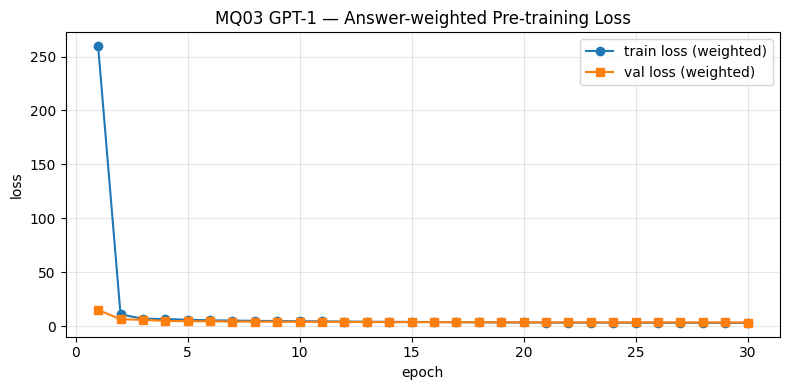

CPU times: user 20min 58s, sys: 5min 26s, total: 26min 25s
Wall time: 1h 37min 44s


In [17]:
%%time
# ================================================================================
# 🎯 [Step 6-B. Pre-training 루프]
# - 매 epoch: train 가중 loss → val 가중 loss
# - val 최저 시 best_model.pt 저장 + Early Stopping (patience)
# - mininterval: 노트북에 tqdm 줄이 수만 줄 쌓이는 문제 완화
# ================================================================================
global_step = 0
best_val_loss = float("inf")
patience_counter = 0
history = []  # (train_loss, val_loss)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    bar = tqdm(
        total=len(train_loader),
        leave=True,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        mininterval=5.0,
        maxinterval=30.0,
    )
    for x, y, w in train_loader:
        global_step += 1
        batch_loss = train_step(x, y, w, model, optimizer, global_step, lr_scheduler)
        train_loss += batch_loss
        bar.set_postfix(loss=f"{batch_loss:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")
        bar.update(1)
    bar.close()

    avg_train = train_loss / len(train_loader)
    avg_val = eval_epoch(model, val_loader)
    history.append((avg_train, avg_val))

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "val_loss": best_val_loss,
                "vocab": word2idx,
                "config": {
                    "n_layers": N_LAYERS,
                    "d_model": D_MODEL,
                    "n_heads": N_HEADS,
                    "answer_loss_weight": ANSWER_LOSS_WEIGHT,
                    "question_loss_weight": QUESTION_LOSS_WEIGHT,
                },
            },
            CHECKPOINT_PATH,
        )
        tqdm.write(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  *best*")
    else:
        patience_counter += 1
        tqdm.write(
            f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  "
            f"(patience {patience_counter}/{PATIENCE})"
        )
        if patience_counter >= PATIENCE:
            tqdm.write("Early Stopping")
            break

print(f"Best val loss (answer-weighted): {best_val_loss:.4f}")

# loss 곡선 (제출·회고 캡처용)
epochs_ran = list(range(1, len(history) + 1))
plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, [h[0] for h in history], "o-", label="train loss (weighted)")
plt.plot(epochs_ran, [h[1] for h in history], "s-", label="val loss (weighted)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("MQ03 GPT-1 — Answer-weighted Pre-training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 7. 생성
프롬프트 `<start> Q <sep>` 이후 답변만 생성.

- Beam / Greedy
- 반복 억제 + **만능 답 패턴 패널티**
  (`잘 할 수 있을 거예요` 등으로 쏠리는 현상 완화)


In [18]:
# ================================================================================
# 🎯 [Step 7. 생성] — 평가 5
# GPT 변경: Encoder→Decoder beam이 아니라 단일 Decoder autoregressive
#
# 생성 개선 이력:
#   1) temperature=1.0 샘플링 → 문장 붕괴
#   2) Beam + 반복 패널티 → 문법은 안정, 만능답("잘 할 수 있을 거예요") 쏠림
#   3) 만능답 패턴 패널티 + 학습(답변가중·스케일업) → 질문 관련성 개선
# ================================================================================

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    try:
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"Best model loaded (epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")
    except RuntimeError as e:
        # n_layers/d_model이 체크포인트와 다르면 발생 → Step 6 재학습 필요
        print("체크포인트 로드 실패 (구조 불일치). Step 6 학습을 다시 실행하세요.")
        print(e)


# 이전 실험에서 Beam이 자주 고르던 만능 답 형태소 패턴
GENERIC_ANSWER_PATTERNS = [
    ["잘", "하", "ᆯ", "수", "있", "을", "거", "이", "예요"],
    ["잘", "하", "ᆯ", "수", "있", "을", "거", "예요"],
    ["좋", "은", "사람", "만나", "ᆯ", "수", "있", "을", "거", "이", "예요"],
]


def _ban_answer_specials(logits):
    """답변 생성 중 <pad>/<start>/<sep> 재등장 차단"""
    for ban_id in (PAD_ID, START_ID, SEP_ID):
        logits[ban_id] = -1e9
    return logits


def _apply_repetition_penalty(logits, generated_ids, penalty=1.3):
    """이미 나온 토큰 logit 억제 (연락 연락… 완화)"""
    if penalty <= 1.0 or not generated_ids:
        return logits
    for tid in set(generated_ids):
        if tid in (PAD_ID, START_ID, END_ID, SEP_ID):
            continue
        val = logits[tid]
        logits[tid] = val / penalty if val > 0 else val * penalty
    return logits


def _apply_generic_penalty(logits, answer_token_strs, penalty=2.5):
    """만능 답 prefix가 진행 중이면 다음 토큰에 패널티"""
    if not answer_token_strs:
        return logits
    for pat in GENERIC_ANSWER_PATTERNS:
        if len(answer_token_strs) >= len(pat):
            continue
        if answer_token_strs != pat[: len(answer_token_strs)]:
            continue
        next_tok = pat[len(answer_token_strs)]
        next_id = word2idx.get(next_tok)
        if next_id is not None:
            logits[next_id] = logits[next_id] - penalty
    return logits


@torch.no_grad()
def generate(
    prompt_tokens,
    max_new_tokens=30,
    strategy="beam",
    beam_size=5,
    length_penalty=0.7,
    temperature=0.8,
    repetition_penalty=1.4,
    generic_penalty=2.5,
):
    """
    strategy: "beam"(기본) | "greedy" | "sample"
    """
    model.eval()
    prompt_ids = encode(prompt_tokens)
    prompt_len = len(prompt_ids)

    def step_logits(ids):
        x = torch.tensor([ids[-MAX_LEN:]], dtype=torch.long, device=device)
        mask = causal_padding_mask(x)
        logits, _ = model(x, mask)
        next_logits = logits[0, -1].clone()
        answer_ids = ids[prompt_len:]
        answer_strs = [idx2word.get(i, "<unk>") for i in answer_ids]
        next_logits = _ban_answer_specials(next_logits)
        next_logits = _apply_repetition_penalty(next_logits, answer_ids, repetition_penalty)
        next_logits = _apply_generic_penalty(next_logits, answer_strs, generic_penalty)
        return next_logits

    if strategy == "greedy":
        ids = list(prompt_ids)
        for _ in range(max_new_tokens):
            next_id = int(torch.argmax(step_logits(ids)).item())
            ids.append(next_id)
            if next_id == END_ID:
                break
        return [idx2word.get(i, "<unk>") for i in ids]

    if strategy == "sample":
        ids = list(prompt_ids)
        for _ in range(max_new_tokens):
            next_logits = step_logits(ids) / max(temperature, 1e-5)
            probs = F.softmax(next_logits, dim=-1)
            next_id = int(torch.multinomial(probs, num_samples=1).item())
            ids.append(next_id)
            if next_id == END_ID:
                break
        return [idx2word.get(i, "<unk>") for i in ids]

    # --- Beam Search ---
    beams = [(0.0, list(prompt_ids))]
    finished = []
    for _ in range(max_new_tokens):
        candidates = []
        for score, ids in beams:
            if ids[-1] == END_ID:
                finished.append((score, ids))
                continue
            log_probs = F.log_softmax(step_logits(ids), dim=-1)
            topk = torch.topk(log_probs, k=beam_size)
            for lp, tid in zip(topk.values.tolist(), topk.indices.tolist()):
                candidates.append((score + float(lp), ids + [int(tid)]))
        if not candidates:
            break

        def norm_score(item):
            sc, ids = item
            gen_len = max(1, len(ids) - prompt_len)
            return sc / (gen_len ** length_penalty)

        candidates.sort(key=norm_score, reverse=True)
        beams = candidates[:beam_size]
        if all(ids[-1] == END_ID for _, ids in beams):
            finished.extend(beams)
            break

    pool = finished if finished else beams
    pool.sort(key=lambda it: it[0] / max(1, len(it[1]) - prompt_len) ** length_penalty, reverse=True)
    return [idx2word.get(i, "<unk>") for i in pool[0][1]]


def chat_generate(question: str, max_new_tokens=30, strategy="beam"):
    """질문 → <start> Q <sep> 프롬프트 → 답변 구간만 반환"""
    q_tok = morphs(preprocess_sentence(question))
    max_q = MAX_LEN - 2  # <start>, <sep>
    if len(q_tok) > max_q:
        q_tok = q_tok[:max_q]
    prompt = ["<start>"] + q_tok + ["<sep>"]
    out = generate(prompt, max_new_tokens=max_new_tokens, strategy=strategy)

    if "<sep>" in out:
        ans = out[out.index("<sep>") + 1 :]
    else:
        ans = out
    if "<sep>" in ans:
        ans = ans[: ans.index("<sep>")]
    ans = [t for t in ans if t not in ("<end>", "<pad>", "<start>", "<sep>")]
    return " ".join(ans), out


TEST_QUESTIONS = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("=== GPT-1 생성 결과 (Beam + 만능답 패널티) ===")
for q in TEST_QUESTIONS:
    ans, full = chat_generate(q, strategy="beam")
    print(f"Q: {q}")
    print(f"A: {ans}")
    print(f"(full) {' '.join(full)}")
    print()

print("=== 참고: Greedy ===")
for q in TEST_QUESTIONS:
    ans, _ = chat_generate(q, strategy="greedy")
    print(f"Q: {q}")
    print(f"A: {ans}")
    print()


Best model loaded (epoch=30, val_loss=3.3341)
=== GPT-1 생성 결과 (Beam + 만능답 패널티) ===
Q: 지루하다, 놀러가고 싶어.
A: 더 좋 은 사람 만나 ᆯ 수 있 을 거 이 예요 .
(full) <start> 지루 하 다 , 놀 러 가 고 싶 어 . <sep> 더 좋 은 사람 만나 ᆯ 수 있 을 거 이 예요 . <end>

Q: 오늘 일찍 일어났더니 피곤하다.
A: 잘 견디 고 있 을 거 이 예요 .
(full) <start> 오늘 일찍 일어나 었 더니 피곤 하 다 . <sep> 잘 견디 고 있 을 거 이 예요 . <end>

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 마음 이 복잡 하 겠 어요 .
(full) <start> 간만에 여자 친구 랑 데이트 하 기 로 하 었 어 . <sep> 마음 이 복잡 하 겠 어요 . <end>

Q: 집에 있는다는 소리야.
A: 사랑 하 었 던 사람 이 니까요 .
(full) <start> 집 에 있 는다는 소리 이 야 . <sep> 사랑 하 었 던 사람 이 니까요 . <end>

=== 참고: Greedy ===
Q: 지루하다, 놀러가고 싶어.
A: 저 도 요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: 저 도 요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 친구 가 아니 ᆫ가 보 어요 .

Q: 집에 있는다는 소리야.
A: 저 도 모르 고 싶 어요 .



## 회고

### 전체 실행 플로우

```mermaid
flowchart TD
  A[Step0 환경] --> B[Step1 ChatbotData]
  B --> C[Step2 전처리: Q truncate / 답빈도 cap]
  C --> D[Step3 Vocab + answer-weighted loss]
  D --> E[Step4 GPT1 Decoder-only]
  E --> F[Step5 Causal mask + weighted CE]
  F --> G[Step6 12L/768 학습 + loss 곡선]
  G --> H[Step7 Beam / Greedy + 만능답 패널티]
```

---

### 이번 제출본 실행 결과 (`MQ03.ipynb`, 최종 재학습)

- Best checkpoint: **epoch 30**, weighted **val_loss ≈ 3.3341**
- 동일 설정(12L/768)으로 다시 학습했을 때, **val loss는 이전 run보다 낮아졌지만** Beam 생성 관련성은 떨어졌다.
- 즉 **loss ↓ ≠ 체감 품질 ↑** 이 실험에서 다시 확인됐다.

| 프롬프트 | 이번 Beam (`MQ03.ipynb`) | 이전 Beam (`MQ03_trained`, val≈3.43) |
|----------|---------------------------|--------------------------------------|
| 지루하다, 놀러가고 싶어. | 더 좋은 사람 만날 수 있을 거예요. (관련성↓) | 같이 놀 거예요. (관련성↑) |
| 오늘 일찍 일어났더니 피곤하다. | 잘 견디고 있을 거예요. | 마음이 복잡한가 보아요. |
| 간만에 여자친구랑 데이트 하기로 했어. | 마음이 복잡하겠어요. (톤 어색) | 좋겠어요. |
| 집에 있는다는 소리야. | 사랑했던 사람이니까요. (관련성↓) | 제가 있잖아요. |

- Greedy는 이번에도 `저도요` 류 **만능 답**으로 잘 붕괴 → Beam+만능답 패널티는 “짧은 만능답 회피”에는 유효하나, **질문과 맞는 답**을 보장하지는 못함.

---

### 개선 실험 기록 (비교)

| 단계 | 설정 요약 | Best val (가중) | 대표 생성 (Beam) | 소감 |
|------|-----------|-----------------|------------------|------|
| **1차** | 4L/256, 균등 CE, T=1.0 sample, epoch15 | ~4.04 | `연락…범죄…` 등 붕괴 | 학습은 되나 생성 품질 최악 |
| **2차** | + Beam/반복억제 | (동일 가중치) | `잘 할 수 있을 거예요` 반복 | 문법은 안정, **만능 답** 쏠림 |
| **3차** | 답변 loss×3, 6L/368, epoch35 | ~3.35 | 일부 맥락 OK + 만능답 잔존 | loss↓와 체감이 부분만 일치 |
| **4차** | 전처리(Q-truncate, 답빈도), 4L | ~3.39 | `위로해 드릴게요`로 또 쏠림 | 레이어를 줄인 건 실수에 가까움 |
| **5차-A** | **12L/768**, 답변×4, Beam+패널티 (이전 run) | **~3.43** | `같이 놀 거예요` 등 관련성↑ | 스케일업이 가장 체감에 유효했던 시점 |
| **5차-B (제출)** | 동일 설정 재학습 (이번 `MQ03.ipynb`) | **~3.33** | 문장은 만들지만 Q와 어긋남 | val은 더 낮음, 생성은 불안정 |

**스케일·재학습 교훈**
- Decoder-only는 **12L/768 스케일**이 4L보다 유리했지만, **같은 하이퍼파라미터라도 seed/셔플에 따라 생성 품질이 크게 흔들릴 수 있다.**
- 제출본은 재실행 결과(5차-B)를 기준으로 하며, 이전 좋은 예문(5차-A)은 **비교용 기록**으로만 남긴다.

---

### 오류·이슈 해결 기록

1. **CSV 다운로드 404**  
   - 원인: `ChatbotData%20.csv` 구 URL  
   - 해결: `ChatbotData.csv` 로 변경 + 로컬 캐시

2. **체크포인트 로드 실패 (`RuntimeError` state_dict)**  
   - 원인: 학습 때 4L/6L과 추론 때 12L 등 **구조 불일치**  
   - 해결: Step 6과 동일 config로 재학습 후 로드 / 로드 실패 시 안내 print

3. **tqdm 출력이 수만 줄로 저장됨**  
   - 원인: 비대화형/노트북 저장 시 진행바 매 업데이트가 새 줄로 기록  
   - 해결: `mininterval` 조정 + 제출용 출력 정리

4. **에디터 “file is newer” / Revert**  
   - 원인: 외부에서 파일 수정 ↔ 에디터 버퍼 충돌  
   - 해결: 디스크가 최신이면 **Revert**

5. **회고와 생성 결과 불일치**  
   - 원인: 회고를 이전 run(`MQ03_trained`, 관련성 좋은 Beam) 기준으로 작성한 뒤, 제출용으로 **같은 설정 재학습** → 새 checkpoint의 다른 답이 나옴  
   - 해결: 회고를 **이번 `MQ03.ipynb` 출력**에 맞게 수정하고, 이전 결과를 비교표로 분리

6. **생성 품질 vs Seq2Seq**  
   - Decoder-only는 Encoder Cross-Attn이 없어 Q↔A 정렬이 약함  
   - 완화 시도: 답변 구간 loss 가중, 답변 빈도 cap, Beam+만능답 패널티, 모델 스케일업  
   - 한계: 만능답 회피 ≠ 의미 정합. 데이터 규모·비결정성 때문에 재학습마다 체감이 갈릴 수 있음

---

### 배운 점
- Transformer → GPT의 핵심은 **Encoder/Cross-Attn 제거 + Causal LM + Learned PE**
- **학습 목표 정렬**(어디에 loss를 줄지)과 **추론 디코딩**을 같이 설계해야 함
- **val loss만으로 회고를 쓰면 안 된다** — 동일/더 낮은 loss여도 예문 품질이 떨어질 수 있음
- 재현성을 높이려면 seed 고정·동일 checkpoint 재사용이 필요 (이번에는 전체 파이프라인 재실행으로 결과가 달라짐)

### 아쉬운 점
- ChatbotData 규모로는 “대화답게”까지는 한계가 있음 (과제 범위: pretrain + 생성 동작)
- `gpt1_best.pt`(~339MB)는 GitHub 제한으로 미업로드 → 로컬 재실행 시마다 답이 달라질 수 있음
- Beam은 짧은 만능답(`저도요`)은 줄이지만, **데이터셋에 흔한 안전 문장**으로 다른 방향으로 쏠릴 수 있음

### 참고
- Radford et al., *Improving Language Understanding by Generative Pre-Training* (2018)
- Vaswani et al., *Attention Is All You Need* (2017)
